# Zillow Home Value Prediction 

<p style="margin-top:50px;"></p>

### Kaggle project link: https://www.kaggle.com/competitions/zillow-prize-1

“Zestimates” are estimated home values based on 7.5 million statistical and machine learning models that analyze hundreds of data points on each property. And, by continually improving the median margin of error (from 14% at the onset to 5% today), Zillow has since become established as one of the largest, most trusted marketplaces for real estate information in the U.S. and a leading example of impactful machine learning.

The **objective** of this project is to predict the log error which is defined as:

$$
\text{logerror} = \log(\text{Zestimate}) - \log(\text{SalePrice})
$$

and it is recorded in the transactions training data provided. 

If a transaction didn't happen for a property during that period of time, that row is ignored and not counted.

For each property (unique parcelid), you must predict a log error for each time point. You should be predicting 6 timepoints: October 2016 (201610), November 2016 (201611), December 2016 (201612), October 2017 (201710), November 2017 (201711), and December 2017 (201712).

# Data Preparation

In [1]:
import pandas as pd
train_2016 = pd.read_csv('train_2016_v2.csv') #target variable (and  time stamp) 
train_2017 = pd.read_csv('train_2017.csv') 
properties_2016 = pd.read_csv('properties_2016.csv', low_memory=False) #property features 
properties_2017 = pd.read_csv('properties_2017.csv', low_memory=False) #identical features, different year

In [2]:
train_2016.shape

(90275, 3)

In [3]:
train_2017.shape

(77613, 3)

**train_2017 only contains data from 01-2017 to 09-2017**

In [4]:
train_2017.transactiondate

0        2017-01-01
1        2017-01-01
2        2017-01-01
3        2017-01-01
4        2017-01-01
            ...    
77608    2017-09-20
77609    2017-09-20
77610    2017-09-21
77611    2017-09-21
77612    2017-09-25
Name: transactiondate, Length: 77613, dtype: object

In [5]:
properties_2016.shape

(2985217, 58)

In [6]:
properties_2017.shape

(2985217, 58)

### Let's have a look at the proportion of Null values in properties_2016

In [7]:
properties_2016.isnull().mean().sort_values(ascending=False) * 100

storytypeid                     99.945599
basementsqft                    99.945465
yardbuildingsqft26              99.911330
fireplaceflag                   99.827048
architecturalstyletypeid        99.796966
typeconstructiontypeid          99.773986
finishedsquarefeet13            99.743000
buildingclasstypeid             99.576949
decktypeid                      99.427311
finishedsquarefeet6             99.263002
poolsizesum                     99.063385
pooltypeid2                     98.925539
pooltypeid10                    98.762603
taxdelinquencyflag              98.108613
taxdelinquencyyear              98.108546
hashottuborspa                  97.688141
yardbuildingsqft17              97.308236
finishedsquarefeet15            93.608572
finishedfloor1squarefeet        93.209304
finishedsquarefeet50            93.209304
threequarterbathnbr             89.560859
fireplacecnt                    89.527160
pooltypeid7                     83.737899
poolcnt                         82

From this initial analysis I have concluded that there are many features present which lack completeness.

This is driven by unique features that only apply to a small number of properties (such as, pools type, basements, yard buildings, fireplaces, garage size etc.) Including some of these features would create sparse vectors which increase the risk of overfitting.

For detail see: Guyon, I., & Elisseeff, A. (2003). An Introduction to Variable and Feature Selection. Journal of Machine Learning Research, 3(Mar):1157–1182. Link: https://www.jmlr.org/papers/volume3/guyon03a/guyon03a.pdf

**We will drop features which have > 95% incompleteness.** 

In [8]:
def drop_features(df, threshold):
    """
    Drops columns with missing values above a certain threshold.
    
    :param df: DataFrame to process
    :param threshold: Proportion of missing values to decide column removal, e.g. 0.95 removes columns with more than 95% of values missing
    :return: Cleaned DataFrame
    """
    missing_percent = df.isnull().mean()
    cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()
    
    return df.drop(columns=cols_to_drop)

properties_2016 = drop_features(properties_2016, 0.95) #drop features of > 95% incompleteness
properties_2017 = drop_features(properties_2017, 0.95)

In [9]:
properties_2016.shape

(2985217, 41)

Before joining our data, we will verify the following:

1. parcelid exists in both the train and properties datasets and is unique. 
2. All unique parcelid's in the train datasets are present in the properties datasets.
3. Features in the 2016 and 2017 datasets are the same.

In [10]:
print(f"train_2016 duplicates: {len(train_2016[train_2016['parcelid'].duplicated(keep=False)])}")
print(f"train_2017 duplicates: {len(train_2017[train_2017['parcelid'].duplicated(keep=False)])}")
print(f"properties_2016 duplicates: {len(properties_2016[properties_2016['parcelid'].duplicated(keep=False)])}")
print(f"properties_2017 duplicates: {len(properties_2017[properties_2017['parcelid'].duplicated(keep=False)])}")

train_2016 duplicates: 249
train_2017 duplicates: 395
properties_2016 duplicates: 0


properties_2017 duplicates: 0


In [11]:
parcelid_2016 = set(properties_2016['parcelid'])
parcelid_2017 = set(properties_2017['parcelid'])

# In 2016 but not in 2017
only_2016 = parcelid_2016 - parcelid_2017
count_only_2016 = len(only_2016)

# In 2017 but not in 2016
only_2017 = parcelid_2017 - parcelid_2016
count_only_2017 = len(only_2017)

print("ParcelIDs in 2016 but not in 2017:", count_only_2016)
print("ParcelIDs in 2017 but not in 2016:", count_only_2017)

ParcelIDs in 2016 but not in 2017: 0
ParcelIDs in 2017 but not in 2016: 0


In [12]:
#All parcelids in train_2016 can be found in properties_2016
print(train_2016['parcelid'].isin(properties_2016['parcelid']).all())

True


In [13]:
if list(train_2016.columns) == list(train_2017.columns):
    print('Columns in train_2016 and train_2017 are identical')
else:
    print('Columns in train_2016 and train_2017 are NOT identical')

if list(properties_2016.columns) == list(properties_2017.columns):
    print('Columns in properties_2016 and properties_2017 are identical')
else:
    print('Columns in properties_2016 and properties_2017 are NOT identical')

Columns in train_2016 and train_2017 are identical
Columns in properties_2016 and properties_2017 are identical


**We can see that the parcelid is not unique in the train datasets.**

**There seem to be duplicates in train which indicate a property being transacted multiple times.**

**Duplicates seem to represent instances in which a property is transacted multiple times in a year (Should be clarified with an SME).**

In [14]:
train_2016[train_2016['parcelid'].duplicated(keep=False)]

,parcelid,logerror,transactiondate
496,13850164,-0.1567,2016-01-05
497,13850164,-0.0460,2016-06-29
781,14677191,-0.3682,2016-01-06
782,14677191,-0.0845,2016-09-12
813,11005771,-0.0131,2016-01-06
...,...,...,...
74547,11419032,-0.0040,2016-12-29
78229,17128287,-0.0030,2016-09-22
78230,17128287,0.0090,2016-11-04
80673,14367791,2.0550,2016-09-29


In [15]:
def compare_properties_datasets(df1, df2, pid):
    """
    Allows us to compare the values in each dataset associated with a given property id side-by-side. If it repeats we will just compare the first.
    
    :param df1, df2: DataFrames to process
    :param pid: Unique property id to visualise 
    :return: df_compare, df with two columns one contains the values for df1 and df2
    """

    row1 = df1.loc[df1['parcelid'] == pid]
    row2 = df2.loc[df2['parcelid'] == pid]
    
    if row1.shape[0] == 0 or row2.shape[0] == 0:
        raise ValueError(f"No row found for parcelid {pid} in one of the DataFrames")

    df_compare = pd.DataFrame({
        'properties_2016': row1.iloc[0],
        'properties_2017': row2.iloc[0]
    })
    
    return df_compare

compare_properties_datasets(properties_2016, properties_2017, 10754147)

,properties_2016,properties_2017
parcelid,10754147,10754147
airconditioningtypeid,NaN,NaN
bathroomcnt,0.0,0.0
bedroomcnt,0.0,0.0
buildingqualitytypeid,NaN,NaN
calculatedbathnbr,NaN,NaN
finishedfloor1squarefeet,NaN,NaN
calculatedfinishedsquarefeet,NaN,NaN
finishedsquarefeet12,NaN,NaN
finishedsquarefeet15,NaN,NaN


In [16]:
compare_properties_datasets(properties_2016, properties_2017, 10759547)

,properties_2016,properties_2017
parcelid,10759547,10759547
airconditioningtypeid,NaN,NaN
bathroomcnt,0.0,0.0
bedroomcnt,0.0,0.0
buildingqualitytypeid,NaN,NaN
calculatedbathnbr,NaN,NaN
finishedfloor1squarefeet,NaN,NaN
calculatedfinishedsquarefeet,NaN,NaN
finishedsquarefeet12,NaN,NaN
finishedsquarefeet15,NaN,NaN


In [17]:
#Compare completeness of 2017 vs 2016
properties_2017.isnull().mean().sort_values(ascending=False) * 100 - properties_2016.isnull().mean().sort_values(ascending=False) * 100

airconditioningtypeid          -0.128734
assessmentyear                 -0.284937
bathroomcnt                    -0.284904
bedroomcnt                     -0.284904
buildingqualitytypeid          -0.097380
calculatedbathnbr              -0.393807
calculatedfinishedsquarefeet   -0.350661
censustractandblock            -0.004723
finishedfloor1squarefeet       -0.034872
finishedsquarefeet12           -0.388648
finishedsquarefeet15            0.020535
finishedsquarefeet50           -0.034872
fips                           -0.284904
fireplacecnt                   -0.016314
fullbathcnt                    -0.393807
garagecarcnt                   -0.259311
garagetotalsqft                -0.259311
heatingorsystemtypeid          -2.102460
landtaxvaluedollarcnt          -0.261522
latitude                       -0.284904
longitude                      -0.284904
lotsizesquarefeet              -0.113660
numberofstories                -0.120829
parcelid                        0.000000
poolcnt         

In [18]:
ids_2016 = set(train_2016['parcelid'])
ids_2017 = set(train_2017['parcelid'])

common_ids = ids_2016.intersection(ids_2017)

print(f"Number of parcelids appearing in both datasets: {len(common_ids)}")

counts_2016 = train_2016[train_2016['parcelid'].isin(common_ids)]['parcelid'].value_counts()
counts_2017 = train_2017[train_2017['parcelid'].isin(common_ids)]['parcelid'].value_counts()

parcelid_counts = pd.DataFrame({
    'count_2016': counts_2016,
    'count_2017': counts_2017
}).fillna(0).astype(int)

parcelid_counts.value_counts()

Number of parcelids appearing in both datasets: 2354


count_2016  count_2017
1           1             2349
2           1                3
1           2                2
Name: count, dtype: int64

**For the purposes of this project, I will try to keep things simple.** 

We will use the 2016 properties data to predict the logerror in 2016 (or **average log error** if a property appears more than once) .

We will discard the 2017 data given that the train data only represents 9/12 months, and the properties data is almost identical. 

We are operating on the basis that log error, and property features are not expected to change meaningfully in our short time period, we will document this as a model assumption. 

Our new objective is therefore to predict the average log error of a Zestimate for a given property which is transacted at least once within 2016, based on the features we engineer. 

We will begin to clean our data as follows:

1. We will remove unnecessary columns. Comments indicate why this column has been selected for removal with reference to the data dictionary.
2. Fill missing values. Comments indicate why missing values were filled by their respective method. 

In [19]:
properties_2016.propertycountylandusecode.value_counts()

propertycountylandusecode
0100    1153896
122      522145
0101     247494
010C     225410
1111     126491
         ...   
030B          1
01MC          1
12T4          1
5011          1
3414          1
Name: count, Length: 240, dtype: int64

In [20]:
properties_2016.regionidneighborhood.value_counts()

regionidneighborhood
118208.0    32267
268496.0    23186
48570.0     21186
27080.0     18891
37739.0     18645
            ...  
764146.0        4
764092.0        3
275855.0        3
275287.0        3
273552.0        1
Name: count, Length: 528, dtype: int64

In [21]:
#remove
drop_cols = ['calculatedbathnbr', #identical to bathroomcnt
             'finishedsquarefeet50', #identical to finishedfloor1squarefeet 
             'fullbathcnt', #This counts number of full bathrooms (sink, shower + bathtub, and toilet) present in home but we already have a feature in bathroomcnt to reflect full bathrooms and water closets 
             'threequarterbathnbr', #see above - this counts number of 3/4 bathrooms in house (shower + sink + toilet) we already have a feature to convey this
             'propertycountylandusecode', #misc alphanumeric values which we have no mapping for many have leading 0's
             'censustractandblock', #Census tract and block ID combined, once again we have no mapping for this
             'rawcensustractandblock', #identical to censustractandblock
             'propertyzoningdesc', #misc alphanumeric values which we have no mapping for
             'regionidneighborhood', #Very similar to regionidzip but less complete
             'latitude', #time-costly to engineer - could use distance based approach (e.g. distance from centre)
             'longitude', #time-costly to engineer - could use distance based approach (e.g. distance from centre)
             'roomcnt', #Values overlap with and sometimes contradict bedroomcnt 
             'unitcnt', #Similar to number of stories, some values contradict
             'taxvaluedollarcnt', #structuretaxvaluedollarcnt + landtaxvaluedollarcnt
             'finishedsquarefeet12', #almost identical to calculatedfinishedsquarefeet 
             'fips' #identical to regionidcounty
            ]

# Drop the columns
properties_2016 = properties_2016.drop(columns=drop_cols, errors="ignore")

print(f"Properties 2016 shape: {properties_2016.shape}")

Properties 2016 shape: (2985217, 25)


In [22]:
train_2016.columns

Index(['parcelid', 'logerror', 'transactiondate'], dtype='object')

In [23]:
properties_2017.columns

Index(['parcelid', 'airconditioningtypeid', 'bathroomcnt', 'bedroomcnt',
       'buildingqualitytypeid', 'calculatedbathnbr',
       'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'finishedsquarefeet15', 'finishedsquarefeet50',
       'fips', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt',
       'garagetotalsqft', 'heatingorsystemtypeid', 'latitude', 'longitude',
       'lotsizesquarefeet', 'poolcnt', 'pooltypeid7',
       'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity',
       'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt',
       'threequarterbathnbr', 'unitcnt', 'yearbuilt', 'numberofstories',
       'structuretaxvaluedollarcnt', 'taxvaluedollarcnt', 'assessmentyear',
       'landtaxvaluedollarcnt', 'taxamount', 'censustractandblock'],
      dtype='object')

In [24]:
#Engineer pooltypeid7 to reflect the fact that it represents pools with hot tubs

properties_2016.loc[properties_2016['poolcnt'] == 1, 'pooltypeid7'] = properties_2016.loc[properties_2016['poolcnt'] == 1, 'pooltypeid7'].apply(lambda x: 0 if x == 1 else 1)

properties_2016.rename(columns={'pooltypeid7': 'hottub'}, inplace=True)

In [25]:
fill_zero = ['fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'poolcnt', 'hottub']

for col in fill_zero:
    properties_2016[col] = properties_2016[col].fillna(0)

In [26]:
fill_median = ['bathroomcnt', 'bedroomcnt', 'numberofstories', 'buildingqualitytypeid', 'finishedfloor1squarefeet', 
               'calculatedfinishedsquarefeet','finishedsquarefeet15', 'lotsizesquarefeet', 'taxamount', 
               'structuretaxvaluedollarcnt', 'landtaxvaluedollarcnt', 'yearbuilt']

for col in fill_median:
    properties_2016[col] = properties_2016[col].fillna(properties_2016[col].median())

In [27]:
fill_mode = ['airconditioningtypeid', 'heatingorsystemtypeid', 'propertylandusetypeid', 'regionidcity', 
             'regionidcounty', 'regionidzip', 'assessmentyear']

for col in fill_mode:
    properties_2016[col] = properties_2016[col].fillna(properties_2016[col].mode()[0])

In [28]:
#Verify that no more null values remain
print(properties_2016.isnull().sum().sum())

0


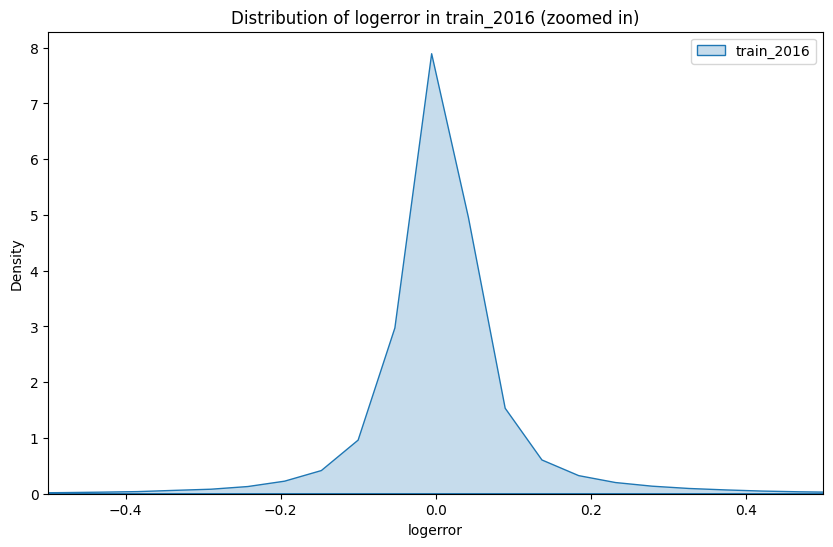

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define zoomed-in x-axis limits (adjust as needed)
x_min, x_max = -0.5, 0.5

# Plot distributions zoomed in
plt.figure(figsize=(10,6))
sns.kdeplot(train_2016['logerror'], label='train_2016', fill=True)
plt.title('Distribution of logerror in train_2016 (zoomed in)')
plt.xlabel('logerror')
plt.ylabel('Density')
plt.xlim(x_min, x_max)
plt.legend()
plt.show()

We will retain the outliers above as our objective is to predict the log error of Zestimates, and the features within these are likely to be the most predictive in terms of what is driving log error. 

In [30]:
# Define the threshold range
lower, upper = -0.5, 0.5

outside_2016 = ((train_2016['logerror'] < lower) | (train_2016['logerror'] > upper)).sum()
total_2016 = len(train_2016)
percentage_2016 = (outside_2016 / total_2016) * 100
print(f"Train 2016: {percentage_2016:.2f}% of logerror values are outside [{lower}, {upper}]")

Train 2016: 1.39% of logerror values are outside [-0.5, 0.5]


In [31]:
def merge_train_properties(train_df, properties_df):
    """
    :param train_df, properties_df: DataFrames to merge
    :return: merged_df, merged df 
    """
    print(f"Merging train data with properties data")
    merged_df = train_df.merge(properties_df, on='parcelid', how='left')
    print(f"Merged dataset shape: {merged_df.shape}")
    return merged_df

train_2016 = train_2016.groupby('parcelid', as_index=False).agg({'logerror': 'mean', 'transactiondate': 'first'})

# Merge train datasets with properties datasets
train_properties = merge_train_properties(train_2016, properties_2016)

Merging train data with properties data


Merged dataset shape: (90150, 27)


In [32]:
train_properties['transactiondate'] = pd.to_datetime(train_properties['transactiondate'])
train_properties['transactiondate'] = train_properties['transactiondate'].dt.strftime('%Y%m').astype(int)

In [33]:
train_properties.shape

(90150, 27)

In [34]:
from sklearn.model_selection import train_test_split

# Step 2: Randomly split 10% as holdout set
data_remainder, holdout_final = train_test_split(train_properties, test_size=0.10, random_state=42)

# Step 3: From the remaining 90%, split 20% as test, and 80% as train
train_final, test_final = train_test_split(data_remainder, test_size=0.20, random_state=42)

# Step 4: Drop 'parcelid' column if needed
train_final = train_final.drop(columns=['parcelid'], errors='ignore')
test_final = test_final.drop(columns=['parcelid'], errors='ignore')
holdout_final = holdout_final.drop(columns=['parcelid'], errors='ignore')

In [35]:
train_final.to_excel('train_final_v1.xlsx', index=False)
test_final.to_excel('test_final_v1.xlsx', index=False)
holdout_final.to_excel('holdout_final_v1.xlsx', index=False)

### Load saved data

In [36]:
import pandas as pd

train_final = pd.read_excel('train_final_v1.xlsx')
test_final = pd.read_excel('test_final_v1.xlsx')
holdout_final = pd.read_excel('holdout_final_v1.xlsx')

print("DataFrames loaded")

DataFrames loaded


In [37]:
X_train = train_final.drop(columns=["logerror"])
y_train = train_final["logerror"].values

X_test = test_final.drop(columns=["logerror"])
y_test = test_final["logerror"].values

X_holdout = holdout_final.drop(columns=["logerror"])
y_holdout = holdout_final["logerror"].values

# Model Training and Evaluation

We will take a simple approach that compares five candidate model architectures:
1. Linear Regression (Baseline model)
2. Gradient-boosted Trees
3. XGBoost
4. Simple Neural Network
5. Neural network with regularisation techniques

## Evaluation Metrics

To assess model performance, we will use the following regression metrics: **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **R-squared ($R^2$)**.

### Mean Squared Error (MSE)

The **Mean Squared Error** measures the average of the squared differences between actual and predicted values:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Interpretation:**  
  Lower MSE indicates better predictive accuracy. It penalizes larger errors more heavily due to the squaring, making it sensitive to outliers.

### Root Mean Squared Error (RMSE)

The **Root Mean Squared Error** is simply the square root of MSE:

$$\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }$$

**Interpretation:**  
  RMSE represents the **average magnitude of prediction error**, measured in the same units as the target variable. A lower RMSE indicates that the model's predictions are, on average, closer to the true values.

### R-squared ($R^2$)

The **R-squared** metric measures the proportion of variance in the target variable that is explained by the model:

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

where $\bar{y}$ is the mean of the true values.

**Interpretation:**  
  $R^2$ ranges from 0 to 1 (or can be negative if the model is worse than predicting the mean).  
  - $R^2 = 1$ → perfect prediction  
  - $R^2 = 0$ → model predicts no better than the mean  
  - $R^2 < 0$ → model performs worse than the mean baseline

A higher $R^2$ indicates a better fit, meaning more of the variance in the target is captured by the model.

These metrics provide a comprehensive view of model accuracy and are used throughout to compare models on a consistent basis.


## Linear Regression (Baseline model)

As a starting point, we will use a **Linear Regression** model to establish baseline performance. Linear regression assumes a linear relationship between the input features and the target variable. The model predicts the target $y$ as a weighted sum of the input features $\mathbf{x}$:

$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p = \beta_0 + \sum_{j=1}^p \beta_j x_j$

where:  
$\hat{y}$ is the predicted value,  
$\beta_0$ is the intercept term,  
$\beta_j$ are the coefficients (weights) for each feature $x_j$,  
$p$ is the number of features.

This provides a simple but important benchmark to compare more complex models against.

The model parameters $\boldsymbol{\beta}$ = ($\beta_0$, $\beta_1$, $\ldots$, $\beta_p$) are estimated by minimising the **Mean Squared Error (MSE)** loss:

$\mathcal{L}(\boldsymbol{\beta}) = \frac{1}{n} \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2 = \frac{1}{n} \sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij} \right)^2$

where $n$ is the number of samples.

Minimizing this loss finds the best linear fit to the data in a least squares sense.

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

linreg_predictions = linreg.predict(X_test_scaled)

mse = mean_squared_error(y_test, linreg_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, linreg_predictions)

print(f"Linear Regression Mean Squared Error (MSE): {mse:.4f}")
print(f"Linear Regression Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Linear Regression R-squared (R2): {r2:.4f}")

import pickle

with open('linreg_model_v1.pkl', 'wb') as f:
    pickle.dump(linreg, f)

Linear Regression Mean Squared Error (MSE): 0.0239
Linear Regression Root Mean Squared Error (RMSE): 0.1545
Linear Regression R-squared (R2): 0.0013


In [39]:
import pickle

with open('linreg_model_v1.pkl', 'rb') as f:
    linreg = pickle.load(f)

X_holdout_scaled = scaler.transform(X_holdout)

holdout_predictions = linreg.predict(X_holdout_scaled)

mse = mean_squared_error(y_holdout, holdout_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_holdout, holdout_predictions)

# Output results
evaluation_results_linreg = [
    f"mse: {mse:.4f}",
    f"rmse: {rmse:.4f}",
    f"r-squared: {r2:.4f}"
]

print(evaluation_results_linreg)

['mse: 0.0254', 'rmse: 0.1594', 'r-squared: 0.0020']


In [40]:
print(linreg.coef_)

[ 1.03935539e-03  8.93821106e-05 -3.52435084e-03  1.56676867e-03
 -3.92404050e-04  1.29699947e-04  1.17744623e-02 -1.11293912e-03
 -4.68479068e-04  1.95533836e-04 -1.50051333e-03 -2.61881980e-03
  1.09285363e-03 -3.02991863e-03 -1.64176832e-03  3.11551735e-03
  5.09449097e-04  1.15056798e-03 -5.60523382e-04 -2.13989433e-04
  2.37799897e-04  1.17442896e-02  7.69783542e-18  1.48698760e-02
 -2.78319753e-02]


## Gradient Boosted Trees

Gradient Boosted Trees (GBTs) are an ensemble learning method that builds a strong predictive model by **sequentially combining many weak learners**—in this case, decision trees. Each tree is trained to correct the errors made by the ensemble of previous trees.

The prediction $\hat{y}_i$ for sample $i$ is the sum of predictions from $M$ individual trees:
$\hat{y}_i = \sum_{m=1}^M f_m(\mathbf{x}_i)$

where each $f_m$ is a decision tree, and $\mathbf{x}_i$ is the feature vector for sample $i$.

Gradient boosting minimises a differentiable loss function $\mathcal{L}$ by adding trees that predict the **negative gradient (residual errors)** of the loss at each iteration:

$\mathcal{L} = \sum_{i=1}^n l(y_i, \hat{y}_i)$

where $l$ is the loss for a single example, such as the squared error:

$l(y_i, \hat{y}_i) = \left(y_i - \hat{y}_i\right)^2$

At each boosting step $m$, the new tree $f_m$ is fitted to the residuals $r_i^{(m)}$ where:

$r_i^{(m)} = - \left[ \frac{\partial l(y_i, \hat{y}_i)}{\partial \hat{y}_i} \right]_{\hat{y}_i = \hat{y}_i^{(m-1)}}$

are the negative gradients calculated from the previous prediction $\hat{y}_i^{(m-1)}$.

By sequentially adding trees to correct errors, the model improves predictions iteratively.

For more detail see: Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. Annals of Statistics, 29(5), 1189–1232. Link: https://jerryfriedman.su.domains/ftp/trebst.pdf


In [41]:
from sklearn.ensemble import GradientBoostingRegressor

gbt = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
)

gbt.fit(X_train, y_train)
predictions = gbt.predict(X_test)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

import pickle

with open('gbt_model_v1.pkl', 'wb') as f:
    pickle.dump(gbt, f)

Mean Squared Error (MSE): 0.0239
Root Mean Squared Error (RMSE): 0.1545
R-squared (R2): 0.0010


In [42]:
with open('gbt_model_v1.pkl', 'rb') as f:
    gbt = pickle.load(f)

holdout_predictions = gbt.predict(X_holdout)

mse = mean_squared_error(y_holdout, holdout_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_holdout, holdout_predictions)

# Output results
evaluation_results_gbt = [
    f"mse: {mse:.4f}",
    f"rmse: {rmse:.4f}",
    f"r-squared: {r2:.4f}"
]

print(evaluation_results_gbt)

['mse: 0.0257', 'rmse: 0.1603', 'r-squared: -0.0091']


## XGBoost: eXtreme Gradient Boosting

**XGBoost** is an optimized implementation of Gradient Boosted Trees (GBTs), designed for speed and performance. It extends the basic gradient boosting framework with several enhancements such as regularization, parallelisation, and improved handling of sparse data.


XGBoost builds trees **sequentially**, just like standard Gradient Boosted Trees (see above). Each tree attempts to correct the residuals (errors) from the sum of the previous trees:

$\hat{y}_i = \sum_{m=1}^M f_m(\mathbf{x}_i), \quad f_m \in \mathcal{F}$

where $\mathcal{F}$ is the space of regression trees.

However, XGBoost improves on GBTs with:

- **Second-order optimization** using both gradients (first order derivatives) and Hessians (second order derivatives)
- **L1 and L2 regularization** on leaf weights
- **Pruning** only removes splits if the loss reduction (gain) is less than a threshold
- **Feature subsampling** for speed and generalisation
- **Built-in handling of missing values**
- **System and Engineering optimisations** (e.g. parallel computing support)

At iteration $t$, XGBoost minimizes a regularized objective:

$\mathcal{L}^{(t)} = \sum_{i=1}^n l(y_i, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)) + \Omega(f_t)$

where $l$ is the loss (e.g., squared error), and the regularization term $\Omega$ penalizes model complexity:

$\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$

- $T$ = number of leaves in the tree  
- $w_j$ = score (weight) of leaf $j$  
- $\gamma$, $\lambda$ = regularization parameters  

This helps control overfitting and encourages simpler models.

For more detail see: Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 785–794). ACM. Link: https://arxiv.org/pdf/1603.02754



In [43]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbosity=1, 
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

mse = mean_squared_error(y_test, xgb_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xgb_predictions)

print(f"XGBoost Mean Squared Error (MSE): {mse:.4f}")
print(f"XGBoost Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"XGBoost R-squared (R2): {r2:.4f}")

xgb_model.save_model('xgboost_model.json')

XGBoost Mean Squared Error (MSE): 0.0238
XGBoost Root Mean Squared Error (RMSE): 0.1542
XGBoost R-squared (R2): 0.0051


In [44]:
xgb_model.load_model('xgboost_model.json')

holdout_predictions = xgb_model.predict(X_holdout)

mse = mean_squared_error(y_holdout, holdout_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_holdout, holdout_predictions)

# Output results
evaluation_results_xgb = [
    f"mse: {mse:.4f}",
    f"rmse: {rmse:.4f}",
    f"r-squared: {r2:.4f}"
]

print(evaluation_results_xgb)

['mse: 0.0255', 'rmse: 0.1596', 'r-squared: -0.0007']


## Simple Neural Network 

Feedforward Neural Networks are comprised of multiple layers. 

Each layer in a neural network is made up of multiple neurons. A neuron performs a simple operation:

$z = w^T x + b$

Where:

$x$ = input vector

$w$ = weights

$b$ = bias

The result $z$ is passed through an **activation function** to introduce nonlinearity.


Data flows forward through the network:

Input layer: Receives the raw input

Hidden layers: Transform the input through weights and activation functions (e.g. ReLU)

Output layer: Produces a prediction (e.g., a single continuous value for regression)

Each layer learns to extract increasingly abstract representations of the input.

Neural networks learn by minimizing a loss function, such as Mean Squared Error (MSE) for regression. The process:

Forward pass: Make predictions $\hat{y}$

Loss computation: Measure how far predictions are from the true labels

Backward pass (backpropagation): Compute gradients of the loss with respect to each weight

Weight update: Use an optimizer (like Adam) to adjust weights and reduce the loss

This is repeated over many epochs (one complete iteration through the training set) until the model converges.

Layer stacking allows deep feature transformations.

Training with large data and efficient optimization leads to models that generalize well to unseen examples.

For detail see: Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. Nature, 323(6088), 533–536. Link: https://gwern.net/doc/ai/nn/1986-rumelhart-2.pdf

Epoch 1/50 | Train Loss: 0.0271 | Val Loss: 0.0242
Epoch 2/50 | Train Loss: 0.0264 | Val Loss: 0.0242


Epoch 3/50 | Train Loss: 0.0262 | Val Loss: 0.0241
Epoch 4/50 | Train Loss: 0.0262 | Val Loss: 0.0240


Epoch 5/50 | Train Loss: 0.0261 | Val Loss: 0.0241


Epoch 6/50 | Train Loss: 0.0261 | Val Loss: 0.0243
Epoch 7/50 | Train Loss: 0.0261 | Val Loss: 0.0239


Epoch 8/50 | Train Loss: 0.0259 | Val Loss: 0.0240


...

Epoch 13/50 | Train Loss: 0.0257 | Val Loss: 0.0240


Epoch 14/50 | Train Loss: 0.0257 | Val Loss: 0.0243


Epoch 15/50 | Train Loss: 0.0257 | Val Loss: 0.0240


Epoch 16/50 | Train Loss: 0.0257 | Val Loss: 0.0241


Epoch 17/50 | Train Loss: 0.0255 | Val Loss: 0.0241
Early stopping triggered at epoch 17


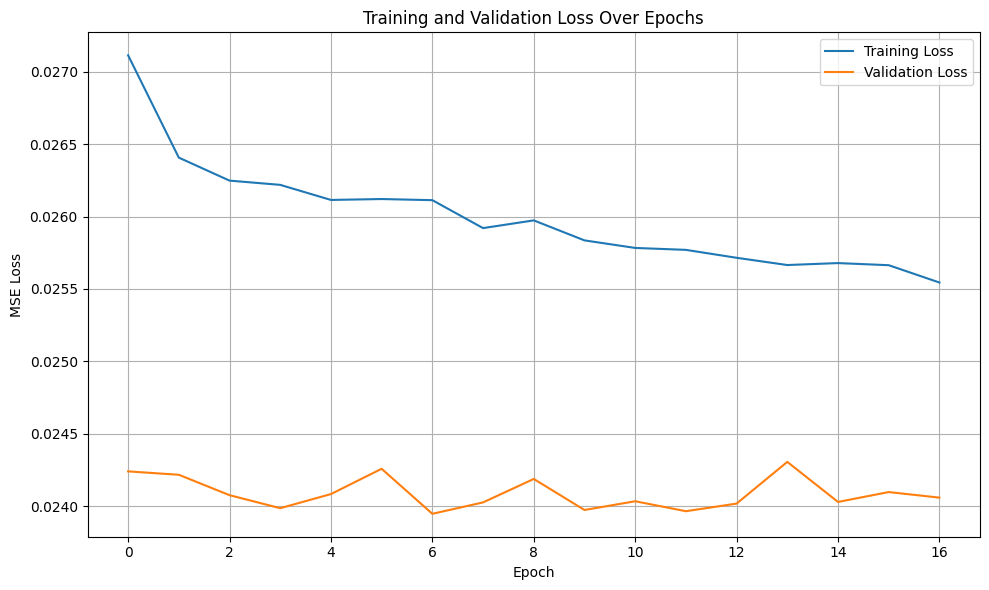

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

class SimpleRegressor(nn.Module):
    def __init__(self):
        super(SimpleRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(25, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
FNN = SimpleRegressor()

criterion = nn.MSELoss()
optimizer = optim.Adam(FNN.parameters(), lr=0.001)

epochs = 50
batch_size = 1024
patience = 10  # Early stopping patience
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []
best_model_state = None

for epoch in range(epochs):
    FNN.train()
    permutation = torch.randperm(X_train_tensor.size(0))
    epoch_loss = 0

    for i in range(0, X_train_tensor.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        batch_X, batch_y = X_train_tensor[indices], y_train_tensor[indices]

        optimizer.zero_grad()
        outputs = FNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss /= X_train_tensor.size(0)
    train_losses.append(epoch_loss)

    FNN.eval()
    with torch.no_grad():
        val_outputs = FNN(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor).item()
        val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = FNN.state_dict()  # Save the best model state
        torch.save(best_model_state, 'best_model_FNN.pth')  # Save model to disk
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

FNN.load_state_dict(torch.load('best_model_FNN.pth'))

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_holdout_scaled_tensor = torch.tensor(scaler.transform(X_holdout), dtype=torch.float32)
y_holdout_tensor = torch.tensor(y_holdout.reshape(-1, 1), dtype=torch.float32)

class SimpleRegressor(nn.Module):
    def __init__(self):
        super(SimpleRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(25, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

FNN = SimpleRegressor()
FNN.load_state_dict(torch.load('best_model_FNN.pth'))
FNN.eval()

with torch.no_grad():
    holdout_pred_tensor = FNN(X_holdout_scaled_tensor)
    holdout_pred = holdout_pred_tensor.numpy().flatten()

mse = mean_squared_error(y_holdout, holdout_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_holdout, holdout_pred)

evaluation_results_fnn = [
    f"mse: {mse:.4f}",
    f"rmse: {rmse:.4f}",
    f"r-squared: {r2:.4f}"
]

print(evaluation_results_fnn)

['mse: 0.0253', 'rmse: 0.1592', 'r-squared: 0.0046']


## Regularization Techniques Used in `Deep_FNN`

To improve generalization and stability of training, several regularization strategies were incorporated into the `Deep_FNN` model.

---

### 1. **Batch Normalization**

Batch Normalization normalizes each feature in the mini-batch such that it has a $\mu$ = 0, $\sigma$ = 1 to reduce internal covariate shift and accelerate training:

$\mu_B = \frac{1}{m} \sum_{i=1}^{m} x_i,$

$\sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2,$

$\hat{x}_i$ = $\frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$

$y_i = \gamma \hat{x}_i + \beta$

- $x_i$: input activation  
- $\mu_B, \sigma_B^2$: batch mean and variance  
- $\gamma, \beta$: learnable scale and shift parameters (initially set to $\gamma$ = 1, $\beta$ = 0 and updated via backpropagation) 
- $\epsilon$: small constant for numerical stability

For detail see: Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. Proceedings of the 32nd International Conference on Machine Learning (ICML), 448–456. Link: https://arxiv.org/pdf/1502.03167

---

### 2. **Dropout**

Dropout helps prevent overfitting by randomly deactivating neurons during training:

$$
\tilde{h}_i = h_i \cdot z_i, \quad z_i \sim \text{Bernoulli}(p)
$$

- $h_i$: neuron activation  
- $z_i$: dropout mask (1 with probability \( p \), otherwise 0)  
- $p$: keep probability (e.g., 0.7 when dropout rate = 0.3)

For detail see: Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. Journal of Machine Learning Research, 15(56), 1929–1958. Link: https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf

---

### 3. **Gradient Clipping**

Gradient Clipping ensures the norm of the gradient vector does not explode by enforcing a threshold:

$$
\text{If } \|g\| > \theta, \quad g \leftarrow \frac{\theta}{\|g\|} \cdot g
$$

- $g$: gradient vector  
- $\theta$: maximum norm threshold (e.g., 1.0)

For detail see Section 3.2/3.3: Pascanu, R., Mikolov, T., & Bengio, Y. (2013). On the difficulty of training recurrent neural networks. Proceedings of the 30th International Conference on Machine Learning (ICML), 1310–1318. Link: https://arxiv.org/pdf/1211.5063

---

### 4. **Learning Rate Scheduling (ReduceLROnPlateau)**

The learning rate is reduced when validation loss plateaus:

$$
\text{If no improvement for } p \text{ epochs:} \quad \text{lr}_{\text{new}} = \text{lr}_{\text{old}} \times \text{factor}
$$

- $p$: patience (number of stagnant epochs, e.g., 3)  
- $\text{factor}$: decay factor (e.g., 0.5)  


Epoch 1/100 | Train Loss: 1.060964 | Val Loss: 0.903257 | RMSE: 0.1546 | R²: 0.0001


Epoch 2/100 | Train Loss: 1.009686 | Val Loss: 0.901168 | RMSE: 0.1544 | R²: 0.0024


Epoch 3/100 | Train Loss: 1.000170 | Val Loss: 0.899961 | RMSE: 0.1543 | R²: 0.0037


Epoch 4/100 | Train Loss: 0.998656 | Val Loss: 0.899824 | RMSE: 0.1543 | R²: 0.0039


Epoch 5/100 | Train Loss: 0.996179 | Val Loss: 0.898853 | RMSE: 0.1542 | R²: 0.0050


...

Epoch 19/100 | Train Loss: 0.987700 | Val Loss: 0.898304 | RMSE: 0.1542 | R²: 0.0056


Epoch 20/100 | Train Loss: 0.986928 | Val Loss: 0.898836 | RMSE: 0.1542 | R²: 0.0050


Epoch 21/100 | Train Loss: 0.986733 | Val Loss: 0.898549 | RMSE: 0.1542 | R²: 0.0053


Epoch 22/100 | Train Loss: 0.985623 | Val Loss: 0.898759 | RMSE: 0.1542 | R²: 0.0051


Epoch 23/100 | Train Loss: 0.985882 | Val Loss: 0.898300 | RMSE: 0.1542 | R²: 0.0056
Early stopping triggered at epoch 23

Final Test Metrics:
MSE: 0.0238 | RMSE: 0.1542 | R²: 0.0059


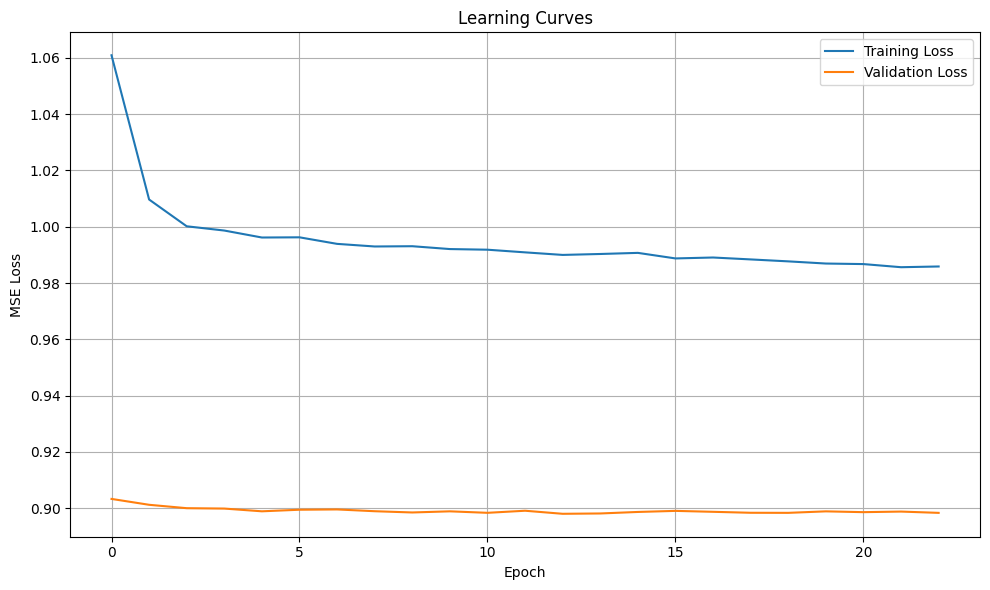

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

class DeepRegressor(nn.Module):
    def __init__(self):
        super(DeepRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(25, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
Deep_FNN = DeepRegressor()

criterion = nn.MSELoss()
optimizer = optim.Adam(Deep_FNN.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

epochs = 100
batch_size = 1024
patience = 10

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(epochs):
    Deep_FNN.train()
    permutation = torch.randperm(X_train_tensor.size(0))
    epoch_loss = 0

    for i in range(0, X_train_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_X, batch_y = X_train_tensor[indices], y_train_tensor[indices]

        optimizer.zero_grad()
        outputs = Deep_FNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(Deep_FNN.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss /= X_train_tensor.size(0)
    train_losses.append(epoch_loss)

    Deep_FNN.eval()
    with torch.no_grad():
        val_outputs = Deep_FNN(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor).item()
        val_losses.append(val_loss)

        # For real-world scale metrics
        val_preds = scaler_y.inverse_transform(val_outputs.cpu().numpy())
        val_true = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())
        val_rmse = np.sqrt(mean_squared_error(val_true, val_preds))
        val_r2 = r2_score(val_true, val_preds)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.6f} | Val Loss: {val_loss:.6f} | RMSE: {val_rmse:.4f} | R²: {val_r2:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = Deep_FNN.state_dict()
        torch.save(best_model_state, 'best_deep_fnn.pth') 
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

Deep_FNN.load_state_dict(torch.load('best_deep_fnn.pth'))

Deep_FNN.eval()
with torch.no_grad():
    final_preds = Deep_FNN(X_test_tensor)
    final_preds_rescaled = scaler_y.inverse_transform(final_preds.numpy())
    y_test_rescaled = scaler_y.inverse_transform(y_test_tensor.numpy())

    final_mse = mean_squared_error(y_test_rescaled, final_preds_rescaled)
    final_rmse = np.sqrt(final_mse)
    final_r2 = r2_score(y_test_rescaled, final_preds_rescaled)

print(f"\nFinal Test Metrics:\nMSE: {final_mse:.4f} | RMSE: {final_rmse:.4f} | R²: {final_r2:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch.nn as nn

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_holdout_scaled = scaler_y.transform(y_holdout.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

X_holdout_scaled_tensor = torch.tensor(scaler.transform(X_holdout), dtype=torch.float32)
y_holdout_tensor = torch.tensor(y_holdout_scaled, dtype=torch.float32)

class DeepRegressor(nn.Module):
    def __init__(self):
        super(DeepRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(25, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

Deep_FNN = DeepRegressor()
Deep_FNN.load_state_dict(torch.load('best_deep_fnn.pth'))
Deep_FNN.eval()

with torch.no_grad():
    y_pred_tensor = Deep_FNN(X_holdout_scaled_tensor)
    y_pred_scaled = y_pred_tensor.numpy().flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

mse = mean_squared_error(y_holdout, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_holdout, y_pred)

evaluation_results_deepfnn = [
    f"mse: {mse:.4f}",
    f"rmse: {rmse:.4f}",
    f"r-squared: {r2:.4f}"
]

print(evaluation_results_deepfnn)

['mse: 0.0252', 'rmse: 0.1587', 'r-squared: 0.0105']


## Hyperparameter tuning

Typically, we would tune the hyperparameters of all candidate models to perform the fairest evaluation of each. However due to compute restraints here, I will tune the hyperparameters for our best performing tree-based model: XGBoost.

In [49]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 2, 3],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1],
    'colsample_bytree': [0.7, 0.8, 0.9, 1],
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [1, 1.5, 2],
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100,
    
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV R2:", random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


Best params: {'subsample': 1, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV R2: 0.010534366843637687


# Therefore, our best XGBoost model is as follows:

In [50]:
from xgboost import XGBRegressor

best_xgb_model = XGBRegressor(
    subsample=1,
    reg_lambda=1.5,
    reg_alpha=0,
    n_estimators=300,
    min_child_weight=3,
    learning_rate=0.01,
    max_depth=6,
    gamma=0,
    colsample_bytree=0.7,
    random_state=42,
    verbosity=1, 
)

best_xgb_model.fit(X_train, y_train)

best_xgb_predictions = best_xgb_model.predict(X_test)

mse = mean_squared_error(y_test, best_xgb_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, best_xgb_predictions)

print(f"Best XGBoost Mean Squared Error (MSE): {mse:.4f}")
print(f"Best XGBoost Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Best XGBoost R-squared (R2): {r2:.4f}")

best_xgb_model.save_model('best_xgboost_model.json')

Best XGBoost Mean Squared Error (MSE): 0.0237
Best XGBoost Root Mean Squared Error (RMSE): 0.1539
Best XGBoost R-squared (R2): 0.0097


In [51]:
best_xgb_model.load_model('best_xgboost_model.json')

holdout_predictions = best_xgb_model.predict(X_holdout)

mse = mean_squared_error(y_holdout, holdout_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_holdout, holdout_predictions)

# Output results
evaluation_results_best_xgb = [
    f"mse: {mse:.4f}",
    f"rmse: {rmse:.4f}",
    f"r-squared: {r2:.4f}"
]

print(evaluation_results_best_xgb)

['mse: 0.0254', 'rmse: 0.1594', 'r-squared: 0.0020']


# Conclusion:

In [52]:
print(evaluation_results_linreg)

['mse: 0.0254', 'rmse: 0.1594', 'r-squared: 0.0020']


In [53]:
print(evaluation_results_gbt)

['mse: 0.0257', 'rmse: 0.1603', 'r-squared: -0.0091']


In [54]:
print(evaluation_results_xgb)

['mse: 0.0255', 'rmse: 0.1596', 'r-squared: -0.0007']


In [55]:
print(evaluation_results_fnn)

['mse: 0.0253', 'rmse: 0.1592', 'r-squared: 0.0046']


In [56]:
print(evaluation_results_deepfnn)

['mse: 0.0252', 'rmse: 0.1587', 'r-squared: 0.0105']


In [57]:
print(evaluation_results_best_xgb)

['mse: 0.0254', 'rmse: 0.1594', 'r-squared: 0.0020']


Overall, our Deep FNN model has the best metrics on the holdout set, as mse and rmse are lowest, and r-squared is highest. However, all r-squared values are close to zero, so the differences between models are small.

# Model Explainability

To make our model more explainable we will review: 
1. Feature importance
2. SHAP values 

## Feature Importance
XGBoost measures feature importance by quantifying how much each feature contributes to improving the model during training. It does this based on how often and how effectively a feature is used to split nodes in the boosted trees.

**Gain (Average Gain)**  
   Measures the average improvement in the loss function (reduction in error) brought by splits using the feature.  
   For a split $s$ on feature $f$, the gain is calculated as:  
    $\text{Gain}(s) = \frac{1}{2} \left( \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right) - \gamma$
    
   where:  
   - $G_L$, $H_L$ = sum of gradients and Hessians in the left child  
   - $G_R$, $H_R$ = sum of gradients and Hessians in the right child  
   - $\lambda$= L2 regularization term on leaf weights  
   - $\gamma$ = complexity penalty for making a split

   The **Gain** for a feature $f$ is the sum or average of gains over all splits using $f$:

   $\text{Gain}(f) = \frac{1}{N_f} \sum_{s \in S_f} \text{Gain}(s)$
   
   where $S_f$ is the set of splits on feature $f$, and $N_f = |S_f|$.

quantifies how much a feature improves model accuracy per split (based on gradients and Hessians), it directly relates to the objective function improvement during training.


In [58]:
importance = best_xgb_model.get_booster().get_score(importance_type='gain') 

total = sum(importance.values())
importance_normalized = {k: v / total for k, v in importance.items()}

sorted_importance = sorted(importance_normalized.items(), key=lambda x: x[1], reverse=True)

for feature, score in sorted_importance:
    print(f"{feature}: {score:.4f}")

airconditioningtypeid: 0.0893
lotsizesquarefeet: 0.0612
buildingqualitytypeid: 0.0573
structuretaxvaluedollarcnt: 0.0499
calculatedfinishedsquarefeet: 0.0476
bathroomcnt: 0.0470
fireplacecnt: 0.0461
regionidzip: 0.0453
taxamount: 0.0452
regionidcounty: 0.0446
landtaxvaluedollarcnt: 0.0434
yearbuilt: 0.0420
finishedfloor1squarefeet: 0.0395
regionidcity: 0.0392
propertylandusetypeid: 0.0379
poolcnt: 0.0368
transactiondate: 0.0330
bedroomcnt: 0.0315
hottub: 0.0311
finishedsquarefeet15: 0.0305
numberofstories: 0.0301
garagetotalsqft: 0.0272
heatingorsystemtypeid: 0.0268
garagecarcnt: 0.0173


## SHAP Values

SHAP values come from game theory and provide a way to fairly measure how much each feature contributes to a model’s prediction.

- Imagine the prediction as a "payout" to be fairly split among all features.  
- The SHAP value for a feature is its **average contribution** to the prediction across all possible combinations of features.  
- Formally, for feature $i$, the SHAP value $\phi_i$ is calculated by averaging the change in prediction when adding feature $i$ to every subset $S$ of features not containing $i$:

$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (|N| - |S| - 1)!}{|N|!} \left[ f_{S \cup \{i\}}(x_{S \cup \{i\}}) - f_S(x_S) \right]$

where:  
- $N$ = all features  
- $f_S(x_S)$ = model prediction using features in subset $S$

For detail see: Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. Advances in Neural Information Processing Systems, 30. Link: https://arxiv.org/pdf/1705.07874

### Interpretation

SHAP values **explain individual predictions** by showing how each feature pushes the prediction higher or lower compared to the average prediction.  

The sum of all SHAP values for a sample equals the difference between that sample’s prediction and the average prediction over all samples.  

Positive SHAP values mean the feature increases the prediction, negative means it decreases the prediction.  

By averaging the absolute SHAP values over many samples, you can find which features are generally the most important to the model.

SHAP values provide a fair and consistent way to assign credit to features for each prediction.  

They show both the **direction** and **magnitude** of feature influence.  

This helps understand how the model makes decisions on both a global level (overall feature importance) and a local level (individual prediction explanations).


In [59]:
import shap

explainer = shap.Explainer(best_xgb_model)

shap_values = explainer(X_train)

#shap.summary_plot(shap_values, X_train)

#shap.dependence_plot('airconditioningtypeid', shap_values.values, X_train)

mean_shap = np.mean(np.abs(shap_values.values), axis=0)

# Create a DataFrame with feature names and mean absolute SHAP values
shap_df = pd.DataFrame({
    'feature': X_train.columns,
    'mean_shap': mean_shap
})

# Sort by descending importance
shap_df_sorted = shap_df.sort_values(by='mean_shap', ascending=False)

# Print the sorted SHAP values
print(shap_df_sorted.reset_index(drop=True).round(5))

                         feature  mean_shap
0                      taxamount    0.00624
1   calculatedfinishedsquarefeet    0.00470
2          landtaxvaluedollarcnt    0.00267
3                      yearbuilt    0.00193
4     structuretaxvaluedollarcnt    0.00192
5                transactiondate    0.00158
6                    regionidzip    0.00107
7              lotsizesquarefeet    0.00106
8                        poolcnt    0.00103
9                     bedroomcnt    0.00096
10                   bathroomcnt    0.00083
11         propertylandusetypeid    0.00067
12                  regionidcity    0.00060
13         heatingorsystemtypeid    0.00041
14                regionidcounty    0.00028
15         buildingqualitytypeid    0.00022
16          finishedsquarefeet15    0.00017
17               garagetotalsqft    0.00010
18                        hottub    0.00009
19               numberofstories    0.00009
20                  garagecarcnt    0.00005
21         airconditioningtypeid

In [60]:
# Choose one instance to explain (e.g., row 100)
instance = X_train.iloc[[100]]  # keep as DataFrame

# Compute SHAP values for the instance
explainer = shap.Explainer(best_xgb_model)
shap_values_single = explainer(instance)

# Get the SHAP values and base value (expected value)
shap_values_array = shap_values_single.values[0]  # shape: (n_features,)
base_value = shap_values_single.base_values[0]    # model's expected value

# Create a DataFrame for all SHAP values of this instance
shap_df_single = pd.DataFrame({
    'feature': X_train.columns,
    'shap_value': shap_values_array
})

# Sort by absolute SHAP importance
shap_df_single['abs_shap'] = np.abs(shap_df_single['shap_value'])
shap_df_single_sorted = shap_df_single.sort_values(by='abs_shap', ascending=False)

# Drop the helper column for clarity
shap_df_single_sorted = shap_df_single_sorted.drop(columns='abs_shap')

# Print the sorted SHAP values
print(shap_df_single_sorted.reset_index(drop=True).round(5))

# Optionally show predicted value breakdown
print(f"\nBase value (expected model output): {base_value:.5f}")
print(f"Predicted value for this instance: {(base_value + shap_values_array.sum()):.5f}")

                         feature  shap_value
0                      taxamount     0.01567
1          landtaxvaluedollarcnt    -0.00563
2                transactiondate     0.00239
3   calculatedfinishedsquarefeet    -0.00227
4     structuretaxvaluedollarcnt    -0.00174
5              lotsizesquarefeet    -0.00116
6                    regionidzip     0.00086
7                   regionidcity    -0.00078
8                      yearbuilt    -0.00060
9                    bathroomcnt    -0.00051
10                    bedroomcnt     0.00050
11         heatingorsystemtypeid     0.00050
12                       poolcnt     0.00035
13                regionidcounty     0.00027
14         buildingqualitytypeid    -0.00013
15          finishedsquarefeet15    -0.00006
16         propertylandusetypeid    -0.00005
17                  garagecarcnt     0.00004
18               garagetotalsqft     0.00004
19                        hottub     0.00003
20      finishedfloor1squarefeet    -0.00002
21        

### Note: This notebook provides a demonstration of how to train and evaluate regression models using a subset of the data. However, deploying a model to production involves many additional considerations beyond model fitting—such as data pipeline design, monitoring for data drift, model versioning, and ensuring reliability, scalability, and maintainability in a real-world environment.